# 01 — Geometry, Static Sag & Θ

Static characterisation of every configuration: chord geometry, midpoint sag
(parabola fit), the dimensionless coupling parameter Θ (from sag and from
material properties) and the predicted quasi-static efficiency
η_pred = 1/(1+Θ).

**Sag method** (`geometry.measure_sag`, defaults used here): full 3-D
perpendicular distances from the chord (the straight line between the first
and last gap sensor), then a parabola constrained through both endpoints is
fitted to the perpendicular offsets, and the sag is the parabola's peak at
mid-span. The RMS residual of that fit is kept as the sag uncertainty.

| § | Content |
|---|---|
| 1 | Load all datasets |
| 2 | Geometry + sag table (with uncertainties) |
| 3 | 3-D / side / top geometry views |
| 4 | Measured vs theoretical sag |
| 5 | Θ comparison: sag-based vs material-based |
| 6 | Export → `results/geometry_sag.npz` |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Editable reload while iterating on the package
%load_ext autoreload
%autoreload 2

import ldv_analysis as la
from ldv_analysis import config, io, analysis, plotting, export

plt.rcParams.update({
    "font.size": 11, "font.family": "serif", "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "figure.dpi": 120, "savefig.dpi": 300, "figure.autolayout": True,
    "axes.titlesize": 11, "axes.labelsize": 10, "axes.linewidth": 0.8,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "axes.grid": True, "grid.alpha": 0.3, "grid.linestyle": "--",
    "lines.linewidth": 1.2,
})
print(f"{len(la.ALL_DATASETS)} datasets in catalogue.")

46 datasets in catalogue.


---
## § 1  Load all sweep datasets

In [2]:
ACTIVE_LABELS = config.SWEEP_LABELS          # all sweep configurations
DATASETS = config.select_datasets(ACTIVE_LABELS)

for cfg in DATASETS:
    io.load_cable_dataset(cfg, verbose=False)
print(f"{len(DATASETS)} datasets loaded.")

42 datasets loaded.


---
## § 2  Geometry & sag table

`analysis.prepare_geometry` sets `chord_unit`, `chord_len`, `static_sag`,
`sag_rms_residual` (parabola-fit residual → sag uncertainty), `theta_pred`
(from sag), `theta_material` (± std over the three E measurements) and
`eta_pred = 1/(1+Θ_sag)`.

In [3]:
SAG_USE_3D       = True   # full 3-D perpendicular distance from the chord
SAG_USE_PARABOLA = True   # parabola fit through the endpoints (outlier-robust)

rows = []
for cfg in DATASETS:
    analysis.prepare_geometry(cfg, sag_use_3d=SAG_USE_3D,
                              sag_use_parabola=SAG_USE_PARABOLA)
    rows.append(dict(
        Label=cfg['label'], Cable=cfg['cable'],
        Gap_cm=int(cfg['gap_m'] * 100),
        L_chord_mm=cfg['chord_len'] * 1e3,
        sag_mm=cfg['static_sag'] * 1e3,
        sag_resid_mm=cfg['sag_rms_residual'] * 1e3,
        Theta_sag=cfg['theta_pred'],
        Theta_mat=cfg['theta_material'],
        Theta_mat_std=cfg['theta_material_std'],
        eta_pred=cfg['eta_pred'],
    ))
df_geo = pd.DataFrame(rows)
df_geo.style.format({'L_chord_mm': '{:.1f}', 'sag_mm': '{:.3f}',
                     'sag_resid_mm': '{:.3f}', 'Theta_sag': '{:.4g}',
                     'Theta_mat': '{:.4g}', 'Theta_mat_std': '{:.2g}',
                     'eta_pred': '{:.3f}'})

,Label,Cable,Gap_cm,L_chord_mm,sag_mm,sag_resid_mm,Theta_sag,Theta_mat,Theta_mat_std,eta_pred
0,Cable1_5cm,Cable1,5,42.1,0.248,0.081,0.008493,7.048e-12,1.6e-12,0.992
1,Cable1_5cm_Sag,Cable1,5,42.1,0.254,0.089,0.008939,7.111e-12,1.6e-12,0.991
2,Cable1_10cm,Cable1,10,91.3,0.387,0.123,0.02078,3.482e-09,7.8e-10,0.980
3,Cable1_10cm_Sag,Cable1,10,91.3,0.511,0.162,0.03614,3.467e-09,7.7e-10,0.965
4,Cable1_15cm,Cable1,15,141.2,0.524,0.128,0.03798,1.138e-07,2.5e-08,0.963
5,Cable1_15cm_Sag,Cable1,15,141.3,0.992,0.324,0.1364,1.143e-07,2.6e-08,0.880
6,Cable2_5cm,Cable2,5,42.1,0.185,0.067,0.004749,1.159e-11,1.8e-12,0.995
7,Cable2_5cm_Sag,Cable2,5,42.1,0.716,0.064,0.07104,1.167e-11,1.8e-12,0.934
8,Cable2_10cm,Cable2,10,91.3,0.221,0.107,0.006788,5.642e-09,8.9e-10,0.993
9,Cable2_10cm_Sag,Cable2,10,91.3,0.659,0.188,0.06012,5.66e-09,8.9e-10,0.943


---
## § 3  Geometry views (subset — edit the slice)

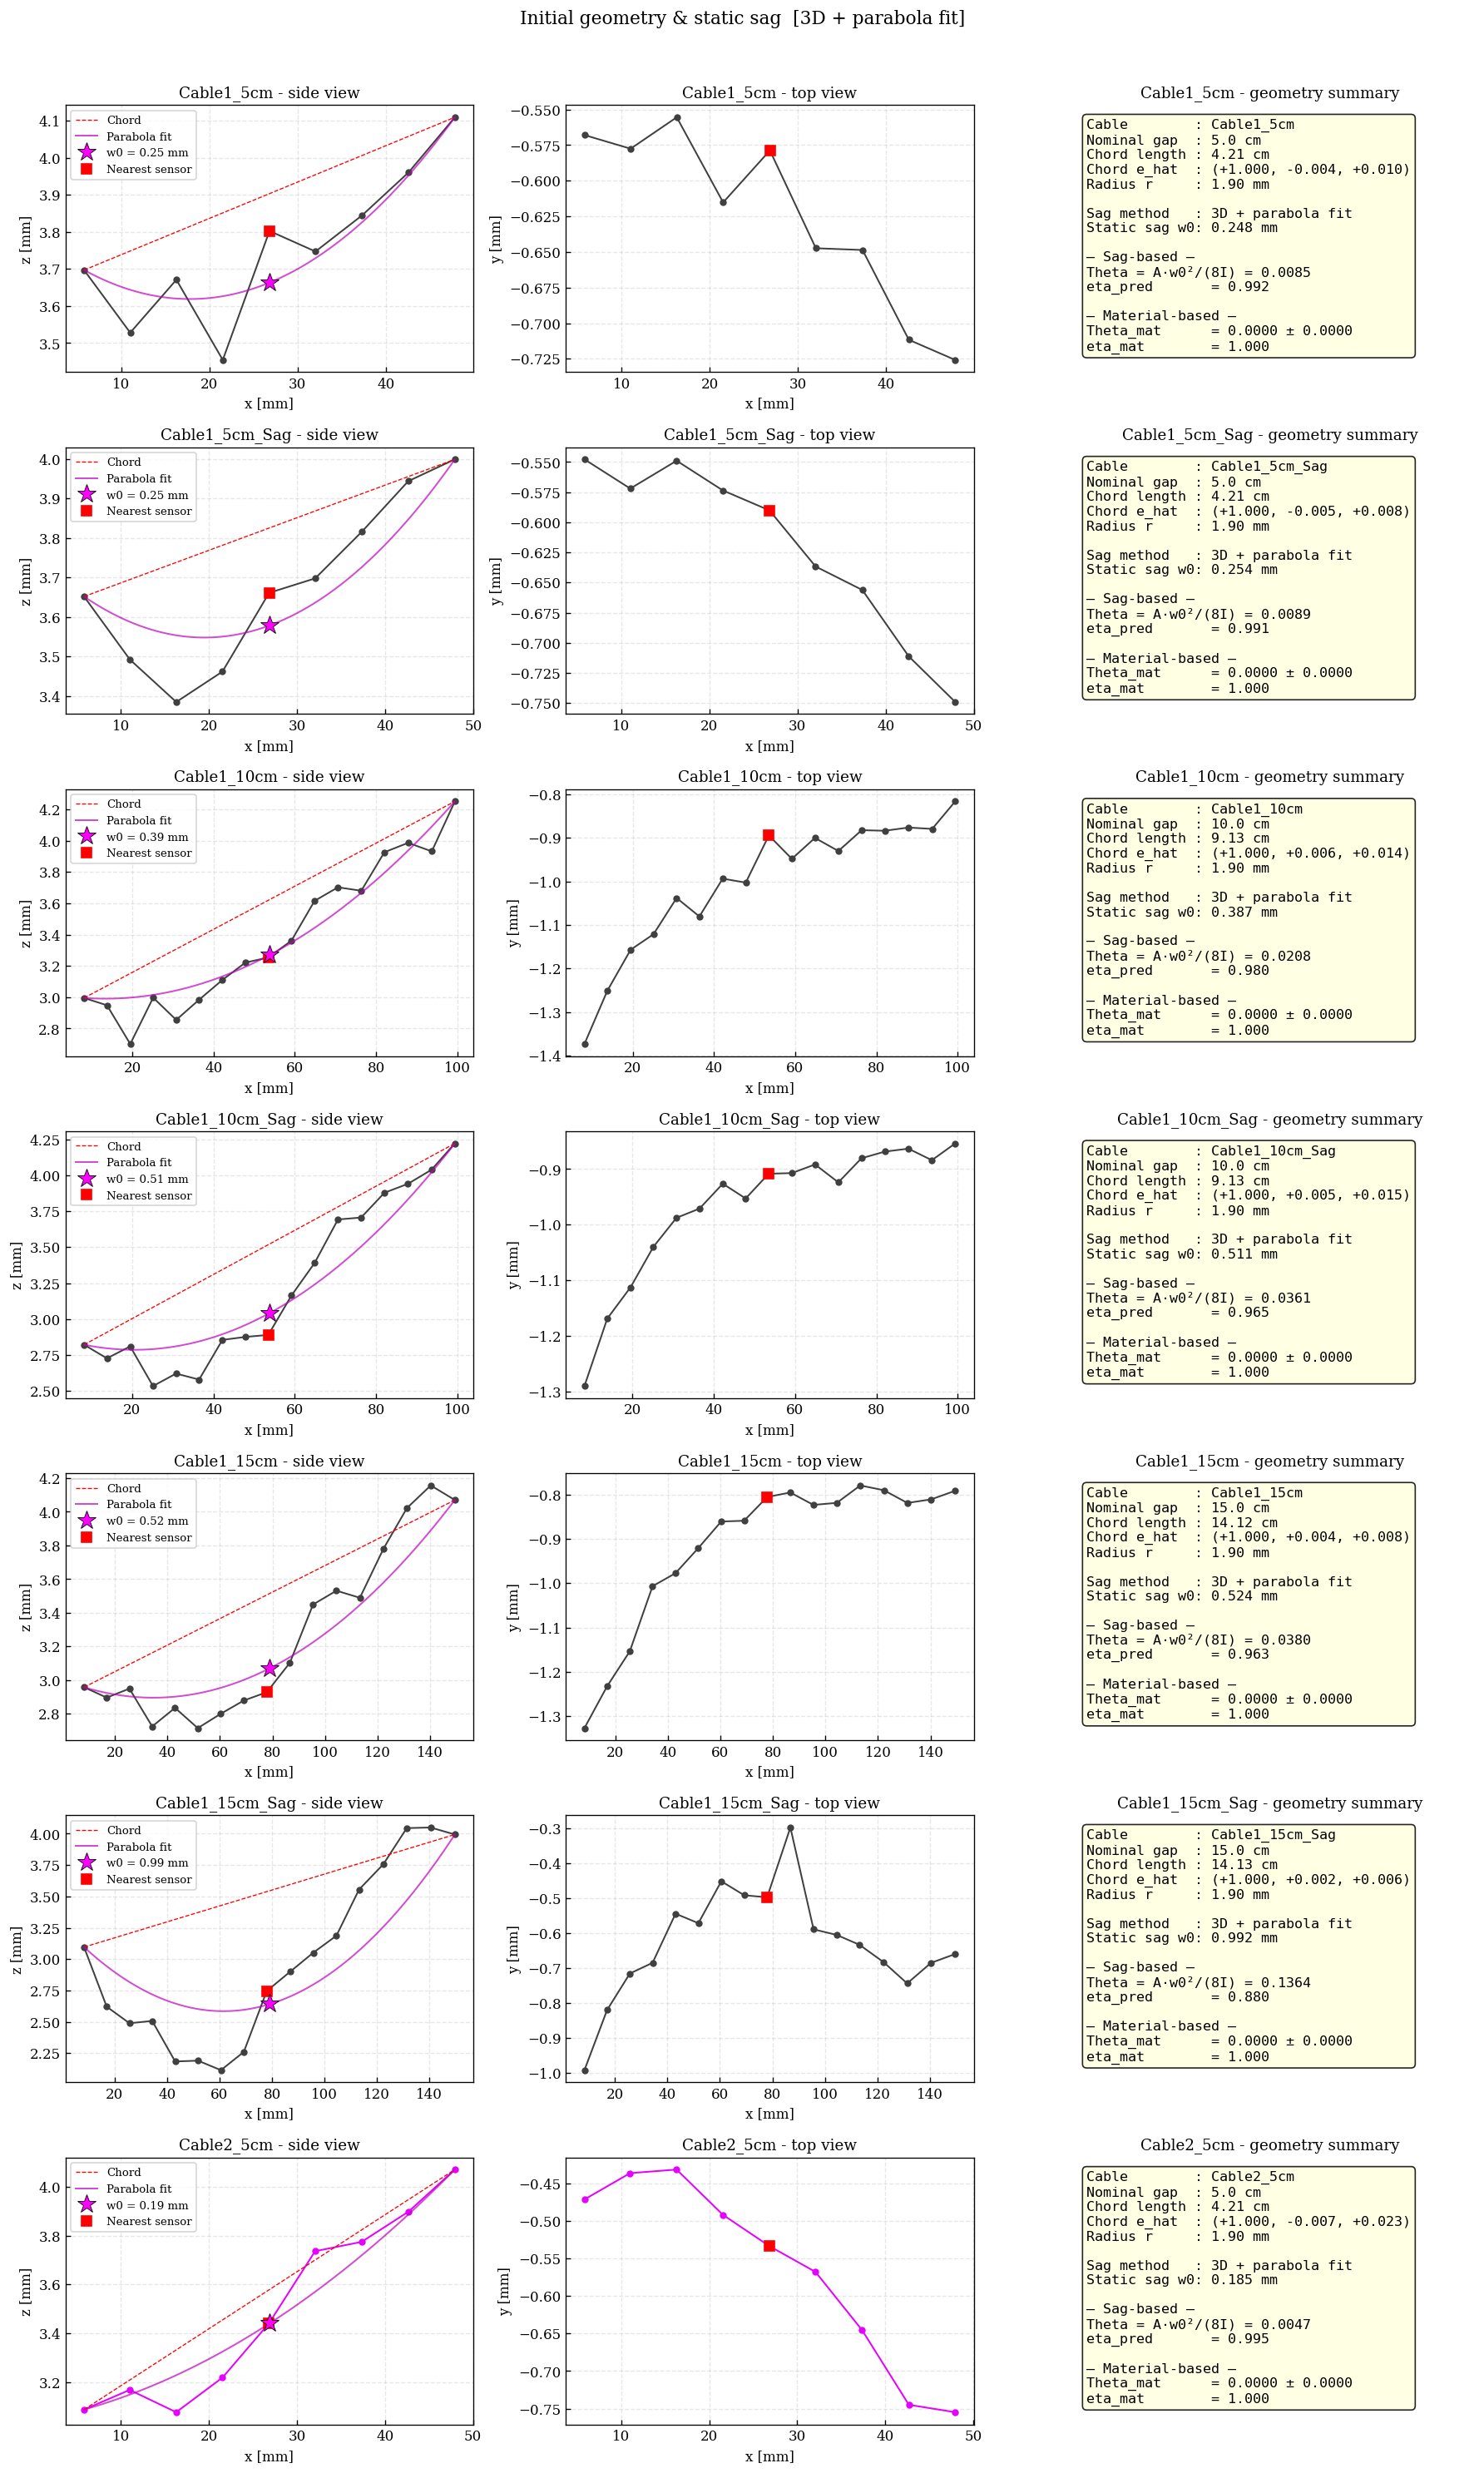

In [5]:
# Side/top view + summary box; heavy for all 42 configs, so plot a subset.
plotting.plot_initial_geometry(DATASETS[:7],
                               sag_use_3d=SAG_USE_3D,
                               sag_use_parabola=SAG_USE_PARABOLA);

---
## § 4  Measured vs theoretical sag

Tension-free analytical midpoint sag (Simone Eq. 8):
$w_0(L/2) = \dfrac{\rho A g L^4}{4\pi^4 E I}$.
Measured points below the theory line indicate residual pretension in the
mounting.

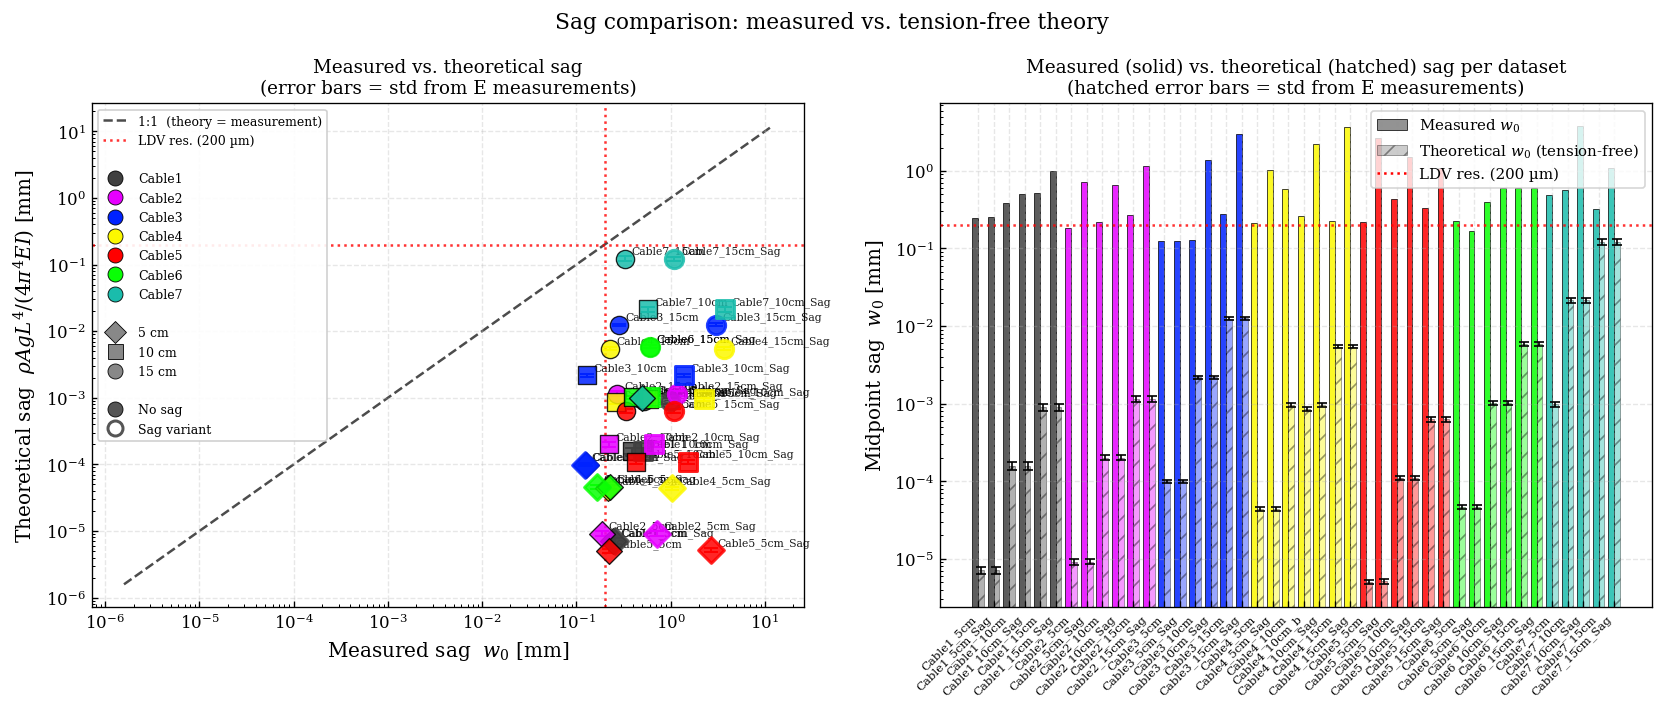

In [6]:
plotting.plot_sag_comparison(DATASETS, unit='mm', annotate=True);

---
## § 5  Θ comparison and Probst Fig. 2a

- `plot_theta_comparison` — Θ from the *measured* sag vs Θ from the material
  properties (tension-free prediction).
- `plot_sag_vs_force_ratio` — dimensionless sag vs force ratio (Probst Fig. 2a
  style).

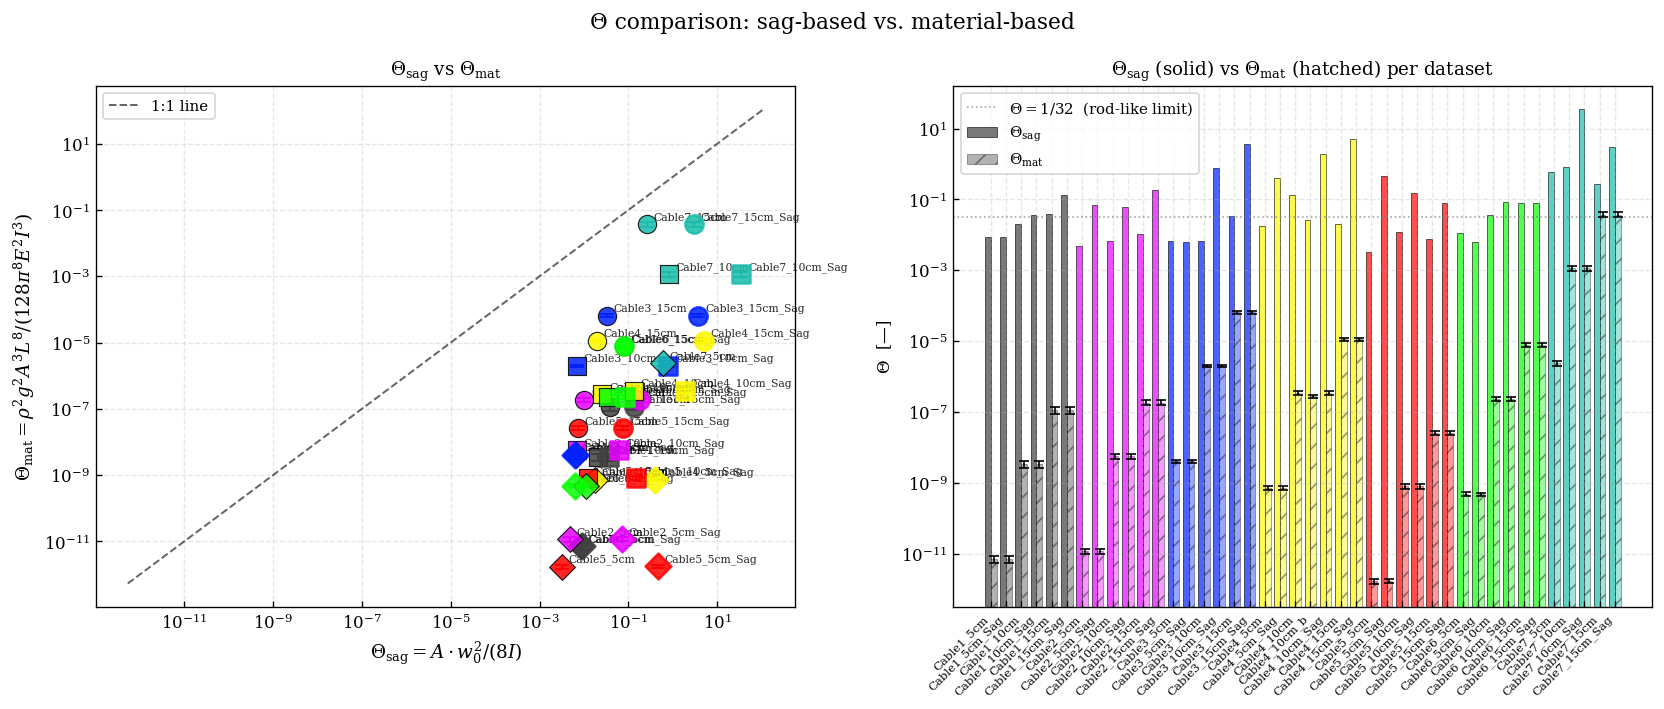

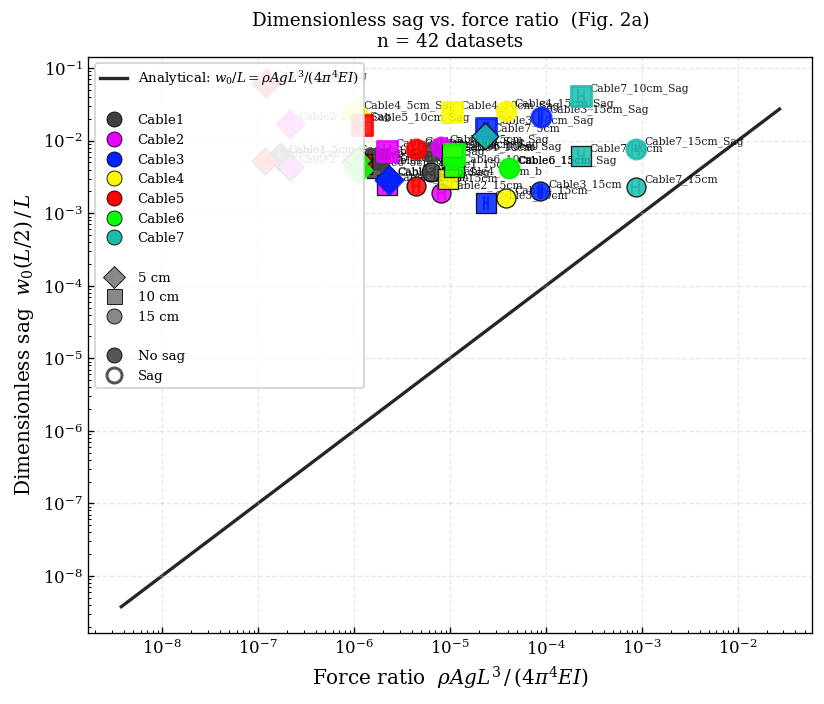

In [7]:
plotting.plot_theta_comparison(DATASETS)
plotting.plot_sag_vs_force_ratio(DATASETS);

---
## § 6  Export

Everything the paper-figure notebook needs to rebuild the sag / Θ figures:
one row per configuration plus the theoretical tension-free sag.

In [8]:
import numpy as np
from ldv_analysis.config import (CABLE_PROPERTIES, cable_section_AI, _E_stats,
                                 GAP_LENGTH_STD_M)

g = 9.81
sag_theory = []
for cfg in DATASETS:
    A, I = cable_section_AI(cfg['cable'])
    E_mean, _ = _E_stats(cfg['cable'])
    rho = CABLE_PROPERTIES[cfg['cable']]['rho']
    L = cfg['chord_len']
    sag_theory.append(rho * A * g * L ** 4 / (4 * np.pi ** 4 * E_mean * I))

export.export_results(
    'geometry_sag',
    meta=dict(sag_use_3d=SAG_USE_3D, sag_use_parabola=SAG_USE_PARABOLA,
              gap_length_std_m=GAP_LENGTH_STD_M),
    labels=[c['label'] for c in DATASETS],
    cable=[c['cable'] for c in DATASETS],
    gap_m=[c['gap_m'] for c in DATASETS],
    is_sag_variant=np.array(['Sag' in c['label'] for c in DATASETS]),
    chord_len=[c['chord_len'] for c in DATASETS],
    sag=[c['static_sag'] for c in DATASETS],
    sag_rms_residual=[c['sag_rms_residual'] for c in DATASETS],
    sag_theory_tension_free=sag_theory,
    theta_sag=[c['theta_pred'] for c in DATASETS],
    theta_material=[c['theta_material'] for c in DATASETS],
    theta_material_std=[c['theta_material_std'] for c in DATASETS],
    eta_pred=[c['eta_pred'] for c in DATASETS],
)

exported geometry_sag.npz: labels(42,), cable(42,), gap_m(42,), is_sag_variant(42,), chord_len(42,), sag(42,), sag_rms_residual(42,), sag_theory_tension_free(42,), theta_sag(42,), theta_material(42,), theta_material_std(42,), eta_pred(42,)


WindowsPath('C:/Users/ocornelius/OneDrive - IMENSUS GmbH/Dokumente/Master_Thesis/Experiment2/Analysis_v2/results/geometry_sag.npz')